<a href="https://colab.research.google.com/github/raokiey/pycon_mini_shizuoka_2026/blob/main/Pycon_mini_Shizuoka_2026_demo_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PythonでWeb地図アプリを作ってみよう**
[Pycon mini Shizuoka 2026](https://shizuoka.pycon.jp/2026/)にて発表した「PythonでWeb地図アプリを作ってみよう」のデモとして作成したNotebookです。  

## **0. 使用するライブラリのインストール**
必要となるPythonライブラリをインストールします。  

In [ ]:
# 今回使用するleafmapをインストール
%pip install leafmap

## **1. 地図の表示**
まずは、地図の表示をやっていきます。  
このNotebookではPycon mini Shizuoka 2026の会場周辺の地図を表示します。  

対象の場所を表示するうえで、まずその緯度経度を知らべる必要があります。  
地理院地図やグーグルマップなどお好みのサービスで表示する場所の緯度経度を調べましょう。  
Pycon mini Shizuoka 2026の会場の緯度経度は以下の通りです。  
緯度: 34.975019度  
経度: 138.386255度  
※ Web地図に表示するうえで、北緯、東経は**プラス**、南緯、西経は**マイナス**の値で示します。  
例えば、ボリビアにあるウユニ塩湖は、南緯20.1770度, 西経67.63601度にありますが、  
緯度は-20.1770度, 経度は-67.63601度と表します。  


それでは、実際に地図の表示を行ってきましょう。  
なんと、**3行**で地図を表示することができます。  

In [ ]:
import leafmap.foliumap as leafmap
m = leafmap.Map(center=[34.975019, 138.386255], zoom=17)
m

`Map`メソッドの引数には以下の3つを指定しています。    
- **center**: 地図の中心の経度、緯度  
  `[緯度、経度]`の順番でリストで指定します。
- **zoom**: 地図のズーム具合を表します。ズーム度合いが低い方から0～22で指定します。  

## **2. マーカー（ピン）の表示**
地図上にマーカー（ピン）を表示していきます。  
今回は、Pycon mini Shizuoka 2026の会場の位置にマーカーを表示します。  
`add_marker`メソッドを用いて簡単に表示できます。

In [ ]:
import leafmap.foliumap as leafmap

# 地図のオブジェクトを作成
m = leafmap.Map(center=[34.975019, 138.386255], zoom=17)
# Pycon mini Shizuoka 2026の会場の位置にマーカーを表示
m.add_marker(location=[34.975019, 138.386255])
m

Pycon mini Shizuoka 2026の会場の位置にマーカーが表示されました！  
続いて、マーカーをクリックするとポップアップが表示され、`ここが会場！`の文字が表示されるようにします。  
`add_marker`メソッドの`popup`引数に指定することで実現できます。  

In [ ]:
import leafmap.foliumap as leafmap

# 地図のオブジェクトを作成
m = leafmap.Map(center=[34.975019, 138.386255], zoom=18)

# Pycon mini Shizuoka 2026の会場の位置にマーカーを表示し、ポップアップを適用
m.add_marker(location=[34.975019, 138.386255], popup="ここが会場")
m

ポップアップが縦書きのようになっていますが、これはポップアップの幅が狭いからです。
また、ポップアップに表示する文字列はHTMLをべた書きするとそのまま反映されます。bタグを用いて太字にしてみましょう。  

In [ ]:
import leafmap.foliumap as leafmap
import folium

# 地図のオブジェクトを作成
m = leafmap.Map(center=[34.975019, 138.386255], zoom=18)

# テキストはHTML形式で指定可能、max_widthでポップアップの幅を変更
# bタグを用いて太字に
popup_html = "<b>ここが会場！</b>"
popup = folium.Popup(popup_html, max_width=200)

# Pycon mini Shizuoka 2026の会場の位置にマーカーを表示し、ポップアップを適用
m.add_marker(location=[34.975019, 138.386255], popup=popup)
m

## **3. ポイントデータの表示**

### **ポイントデータとは？**
特定の位置を示す最も基本的な位置情報の形状です。ポイントは(x, y)のように特定の1地点を表します。(x, y, z)のように3次元でも表すことができます。

例えば、店舗の場所やバス停の場所など、特定の場所などを表すときに使われています。  

### **使用するデータ**
様々な位置情報付きのデータが公開されています。ここでは静岡県のオープンデータカタログサイトである [ふじのくにオープンデータカタログ](https://opendata.pref.shizuoka.jp//) から、「[しずまえおさかな処マップ　掲載飲食店](https://opendata.pref.shizuoka.jp/dataset/12287.html)」を使用します。   

まずは、データをpandasで読み込み確認してみましょう。     

In [ ]:
import pandas as pd

dataset_url = "https://raokiey.github.io/pycon_mini_shizuoka_2026/data/shizumae_dataset.csv"

# CSV形式のデータセットをpandasでDataFrameとして読み込む
df = pd.read_csv(dataset_url)
df.head()

,スポット名,名称カナ,郵便番号,都道府県,市区町村,住所１,住所２,緯度,経度,詳細,営業時間,定休日,駐車場,平均予算,電話番号,URL
0,日本料理うおかね,NaN,420-0867,静岡県,静岡市葵区馬場町,33,NaN,34.978954,138.378316,創業嘉永弐年(1849年)より地元食材を中心に提供しています。特に駿河湾特産の桜海老のかき揚...,コース料理（要予約）11:00～21:00 \n昼 11:30～14:00（L.O13:30...,月曜（コース料理を除く）,NaN,NaN,054-252-0394,http://www2.wbs.ne.jp/~uokane/
1,入船鮨 葵タワー店,いりふねずし あおいたわーてん,420-0852,静岡県,静岡市,葵区紺屋町17-1 地下１階,NaN,34.972754,138.386376,全席禁煙。音楽はJAZZ、足下には荷物入れがある女性に大人気の鮨店です。一品料理もリーズナブ...,11:00～22:00,年中無休,NaN,NaN,054-251-9178,http://irifunesushi.net/
2,入船鮨 南町店,NaN,422-8067,静岡県,静岡市駿河区,南町6-6,NaN,34.970002,138.389354,駅から徒歩3分、リーズナブルな価格で本格江戸前鮨を味わえます。\n静岡の繁華街で創業して百年...,11:00～22:30,火曜,NaN,NaN,054-282-1158,http://irifunesushi.net/
3,入船鮨 登呂店,いりふねずし とろてん,NaN,静岡県,静岡市,駿河区有東2-3-29,NaN,34.961706,138.405866,郊外店らしい家族向けメニューを多数取り揃えております。にぎりもコース料理も明朗会計なので\n...,NaN,NaN,NaN,NaN,054-284-5151,http://irifunesushi.net/
4,驛前松乃鮨,NaN,NaN,静岡県,静岡市,葵区御幸町9-3,NaN,34.973368,138.387556,静岡駅前にて創業８０年をこえました。静岡の地の魚をメインに、旬の味をお届けしています。\nそ...,NaN,NaN,NaN,NaN,054-251-0123,http://ekimatu.web.fc2.com/


スポット名に店名が格納されており、緯度、経度も格納されていることが分かります。  
地図にスポット名、詳細、電話番号、URLを表示することにしましょう。  
NaNの値も多いので、いったんDataFrameを表示用に加工しましょう。  

In [ ]:
# NaNなどがあるので、表示用にきれいにしたDataFrameを作成する
display_df = df.copy()
# '詳細'列のNaN値を'情報なし'に置換
display_df["詳細"] = display_df["詳細"].fillna("情報なし")
# '電話番号'列のNaN値を'情報なし'に置換
display_df["電話番号"] = display_df["電話番号"].fillna("情報なし")
# 'URL'列のNaN値をクリッカブルなHTML形式に変換し、NaNなら'情報なし'に置換
display_df['URL'] = display_df['URL'].apply(lambda x: f"<a href='{x}' target='_blank'>{x}</a>" if pd.notna(x) else '情報なし')
display_df.head()

,スポット名,名称カナ,郵便番号,都道府県,市区町村,住所１,住所２,緯度,経度,詳細,営業時間,定休日,駐車場,平均予算,電話番号,URL
0,日本料理うおかね,NaN,420-0867,静岡県,静岡市葵区馬場町,33,NaN,34.978954,138.378316,創業嘉永弐年(1849年)より地元食材を中心に提供しています。特に駿河湾特産の桜海老のかき揚...,コース料理（要予約）11:00～21:00 \n昼 11:30～14:00（L.O13:30...,月曜（コース料理を除く）,NaN,NaN,054-252-0394,<a href='http://www2.wbs.ne.jp/~uokane/' targe...
1,入船鮨 葵タワー店,いりふねずし あおいたわーてん,420-0852,静岡県,静岡市,葵区紺屋町17-1 地下１階,NaN,34.972754,138.386376,全席禁煙。音楽はJAZZ、足下には荷物入れがある女性に大人気の鮨店です。一品料理もリーズナブ...,11:00～22:00,年中無休,NaN,NaN,054-251-9178,<a href='http://irifunesushi.net/' target='_bl...
2,入船鮨 南町店,NaN,422-8067,静岡県,静岡市駿河区,南町6-6,NaN,34.970002,138.389354,駅から徒歩3分、リーズナブルな価格で本格江戸前鮨を味わえます。\n静岡の繁華街で創業して百年...,11:00～22:30,火曜,NaN,NaN,054-282-1158,<a href='http://irifunesushi.net/' target='_bl...
3,入船鮨 登呂店,いりふねずし とろてん,NaN,静岡県,静岡市,駿河区有東2-3-29,NaN,34.961706,138.405866,郊外店らしい家族向けメニューを多数取り揃えております。にぎりもコース料理も明朗会計なので\n...,NaN,NaN,NaN,NaN,054-284-5151,<a href='http://irifunesushi.net/' target='_bl...
4,驛前松乃鮨,NaN,NaN,静岡県,静岡市,葵区御幸町9-3,NaN,34.973368,138.387556,静岡駅前にて創業８０年をこえました。静岡の地の魚をメインに、旬の味をお届けしています。\nそ...,NaN,NaN,NaN,NaN,054-251-0123,<a href='http://ekimatu.web.fc2.com/' target='...


### **地図上に表示**
DataFrameの内容が表示用にきれいになりました。  
それでは、地図に表示していきましょう！
大量のポイントデータを読み込み、地図上に表示していきます。  
基本的には、for文でDataFrameの内容を1つずつ抽出しながらポップアップに表示する内容を装飾、地図に追加を繰り返していきます。  

In [ ]:
import leafmap.foliumap as leafmap
import folium
import pandas as pd

# 地図のオブジェクトを作成
m = leafmap.Map(center=[34.975019, 138.386255], zoom=15)

# 既存タイルレイヤーのattributionを上書き
for key, tile in m._children.items():
    if isinstance(tile, folium.TileLayer):
        tile.options['attribution'] += (
            ' | <a href="https://opendata.pref.shizuoka.jp/dataset/12287.html">'
            'しずまえおさかな処マップ　掲載飲食店</a>'
        )
        break

# 会場のマーカーを表示
popup_html = "ここが会場！"
popup = folium.Popup(popup_html, max_width=200)
m.add_marker(location=[34.975019, 138.386255], popup=popup)

# DataFrameの内容を走査して、地図上に追加
for idx, row in display_df.iterrows():
      popup_html = f"<b>{row['スポット名']}</b><br>詳細: {row['詳細']}<br>電話番号: {row['電話番号']}<br>URL: {row['URL']}"
      popup = folium.Popup(popup_html, max_width=300)

      # 地図上に情報を追加
      folium.Marker(
          location=[row['緯度'], row['経度']],
          popup=popup,
      ).add_to(m)

m

地図上に「しずまえおさかな処マップ　掲載飲食店」のデータが表示され、ポップアップに指定した情報も表示されています。  
このままだと、味気ないのでマーカーのアイコンも変えてみましょう。  
今回は、事前に用意した以下の魚のアイコンを使用します。  
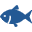

### **カスタムアイコンの表示**
ここでは、`folium.CustomIcon`を使用して、用意した画像をマーカーのアイコンとして表示する方法を示します。`icon_image`にご自身の画像ファイルのURLを指定し、`icon_size`でアイコンのサイズを調整してください。

**注意点:**
*   `icon_image`には、アクセス可能な画像ファイルのURL（例: Google DriveやGitHubなどで公開されている画像）を指定してください。
*   アイコンのサイズは、画像の実際のサイズに合わせて調整することで、適切に表示されます。

In [ ]:
import leafmap.foliumap as leafmap
import folium
from folium.plugins import MarkerCluster  # ← 追加
import pandas as pd

# 地図のオブジェクトを作成
m = leafmap.Map(center=[34.975019, 138.386255], zoom=15)

# 既存タイルレイヤーのattributionを上書き
for key, tile in m._children.items():
    if isinstance(tile, folium.TileLayer):
        tile.options['attribution'] += (
            ' | <a href="https://opendata.pref.shizuoka.jp/dataset/12287.html">'
            'しずまえおさかな処マップ　掲載飲食店</a>'
        )
        break

# 会場のマーカーを表示
popup_html = "ここが会場！"
popup = folium.Popup(popup_html, max_width=200)
m.add_marker(location=[34.975019, 138.386255], popup=popup)

# 表示したいアイコンのパスとサイズを定義
custom_icon_url = "https://raokiey.github.io/pycon_mini_shizuoka_2026/data/fish_icon.png"
icon_size = (36, 36)

# DataFrameの内容を走査して、地図上に追加
for idx, row in display_df.iterrows():
      popup_html = f"<b>{row['スポット名']}</b><br>詳細: {row['詳細']}<br>電話番号: {row['電話番号']}<br>URL: {row['URL']}"
      popup = folium.Popup(popup_html, max_width=300)

      # カスタムアイコンの設定
      custom_icon = folium.CustomIcon(
          icon_image=custom_icon_url,
          icon_size=icon_size
      )

      # 地図上に情報を追加、「icon」引数で設定したアイコンを反映
      folium.Marker(
          location=[row['緯度'], row['経度']],
          popup=popup,
          icon=custom_icon
      ).add_to(m)

m

### **密集している個所をまとめて表示**
魚のアイコンが表示されましたが。密集しているところは見栄えが悪いです。  
`MarkerCluster`を用いて、近接する複数のマーカーを1つのグループにまとめて表示していきます。  

In [ ]:
import leafmap.foliumap as leafmap
import folium
from folium.plugins import MarkerCluster  # ← 追加
import pandas as pd

# 地図のオブジェクトを作成
m = leafmap.Map(center=[34.975019, 138.386255], zoom=15)

# 既存タイルレイヤーのattributionを上書き
for key, tile in m._children.items():
    if isinstance(tile, folium.TileLayer):
        tile.options['attribution'] += (
            ' | <a href="https://opendata.pref.shizuoka.jp/dataset/12287.html">'
            'しずまえおさかな処マップ　掲載飲食店</a>'
        )
        break

# 会場のマーカーを表示
popup_html = "ここが会場！"
popup = folium.Popup(popup_html, max_width=200)
m.add_marker(location=[34.975019, 138.386255], popup=popup)

# カスタムアイコンのパスとサイズを定義
custom_icon_url = "https://raokiey.github.io/pycon_mini_shizuoka_2026/data/fish_icon.pn"
icon_size = (36, 36)

# MarkerClusterを作成して地図に追加
marker_cluster = MarkerCluster(name="しずまえおさかな処マップ　掲載飲食店").add_to(m)

# DataFrameの内容を走査して、地図上に追加
for idx, row in display_df.iterrows():
    if pd.notna(row['緯度']) and pd.notna(row['経度']):
        popup_html = f"<b>{row['スポット名']}</b><br>詳細: {row['詳細']}<br>電話番号: {row['電話番号']}<br>URL: {row['URL']}"
        popup = folium.Popup(popup_html, max_width=300)

        # カスタムアイコンの設定
        custom_icon = folium.CustomIcon(
            icon_image=custom_icon_url,
            icon_size=icon_size
        )

        # add_toの対象をmからmarker_clusterに変更
        folium.Marker(
            location=[row['緯度'], row['経度']],
            popup=popup,
            icon=custom_icon
        ).add_to(marker_cluster)

m

では、Webアプリとして使えるようにHTMLとして出力しましょう。

In [ ]:
save_html_path = "./shizumae_map.html"
m.to_html(save_html_path)

出力されたHTMLをGitHub Pagesなどお好きなサービスでホスティングすれば、誰でも見ることができます。  
今回作ったHTMLは、以下で公開しています。  
https://raokiey.github.io/pycon_mini_shizuoka_2026/shizumae_map.html